# Model Implementations

This notebook presents a structured workflow for forecasting the monthly average interest rate with statistical, machine learning, and deep learning models.

The analysis is organized into four stages:
1. load and validate the data,
2. examine the time-series structure,
3. build a consistent transformed modeling frame,
4. compare forecasting models under the same rolling evaluation scheme.



In [2]:
from pathlib import Path
import itertools
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import boxcox
from scipy.special import inv_boxcox

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.tsa.statespace.sarimax import SARIMAX

import optuna
import torch
import torch.nn as nn
import torch.optim as optim

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fix random seeds so that model runs are reproducible.
SEED = 112
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 1. Configuration and data loading

This section defines the shared constants used throughout the notebook and loads the training data in chronological order. 

In [3]:
DATA_PATH = Path("../Data/train.csv")

# Column names used throughout the notebook.
DATE_COL = "Month"
TARGET_COL = "int_rate_mean"
TREASURY_COL = "Treasury_data"
OPTIONAL_DRIVER_COL = "fed_rate"

# Diagnostics and transformation settings.
SEASONAL_PERIOD = 12
MAX_DIAGNOSTIC_LAGS = 48







def load_training_data(path: Path) -> pd.DataFrame:
    """Load the dataset, parse dates, and sort rows chronologically."""
    df = pd.read_csv(path)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    return df


train = load_training_data(DATA_PATH)

print(f"Dataset shape: {train.shape}")
print(f"Date range: {train[DATE_COL].min().date()} to {train[DATE_COL].max().date()}")
print("\nColumns:")
print(train.columns.tolist())

train.head()

Dataset shape: (104, 9)
Date range: 2007-06-01 to 2016-01-01

Columns:
['Month', 'int_rate_mean', 'int_rate_median', 'int_rate_std', 'loan_amnt_sum', 'loan_amnt_mean', 'loan_amnt_count', 'Treasury_data', 'fed_rate']


,Month,int_rate_mean,int_rate_median,int_rate_std,loan_amnt_sum,loan_amnt_mean,loan_amnt_count,Treasury_data,fed_rate
0,2007-06-01,9.814583,9.640,1.886434,91850.0,3827.083333,24,4.61,5.25
1,2007-07-01,11.158571,10.590,2.830279,348325.0,5528.968254,63,4.82,5.26
2,2007-08-01,11.543514,11.065,3.116487,515300.0,6963.513514,74,4.20,5.02
3,2007-09-01,12.463208,11.860,3.157293,372950.0,7036.792453,53,3.89,4.94
4,2007-10-01,12.438476,12.490,2.698128,753225.0,7173.571429,105,3.90,4.76


In [82]:
# Missing-value checks are shown.
missing_summary = (
    train.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
    .assign(dtype=train.dtypes.astype(str).values)
)

missing_summary

,missing_values,dtype
Month,0,datetime64[ns]
int_rate_mean,0,float64
int_rate_median,0,float64
int_rate_std,0,float64
loan_amnt_sum,0,float64
loan_amnt_mean,0,float64
loan_amnt_count,0,int64
Treasury_data,0,float64
fed_rate,0,float64


## 2. Exploratory diagnostics

These plots provide a quick view of serial dependence, potential relationships with external drivers, and the overall correlation structure among the numeric variables. The goal is to identify patterns that can inform the feature set and model choice.

In [83]:
def plot_series_diagnostics(series: pd.Series, title: str, lags: int = MAX_DIAGNOSTIC_LAGS) -> None:
    """Plot ACF and PACF for a single series after dropping missing values."""
    clean_series = series.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(clean_series, lags=lags, ax=axes[0], alpha=0.05)
    plot_pacf(clean_series, lags=lags, ax=axes[1], method="ywm", alpha=0.05)

    axes[0].set_title(f"ACF: {title}")
    axes[1].set_title(f"PACF: {title}")

    for ax in axes:
        ax.set_xlabel("Lag")
        ax.set_ylabel("Correlation")

    plt.tight_layout()
    plt.show()


def plot_cross_correlation(target: pd.Series, driver: pd.Series, title: str, max_lag: int = 10) -> None:
    """Plot the leading cross-correlations between a target and a driver series."""
    aligned = pd.concat([target, driver], axis=1).dropna()
    cross_corr = ccf(aligned.iloc[:, 0], aligned.iloc[:, 1])

    plt.figure(figsize=(8, 4))
    plt.bar(range(max_lag), cross_corr[:max_lag])
    plt.title(title)
    plt.xlabel("Lag")
    plt.ylabel("Cross-correlation")
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame) -> None:
    """Display the pairwise correlation matrix for the numeric columns."""
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5,
        square=True,
    )
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

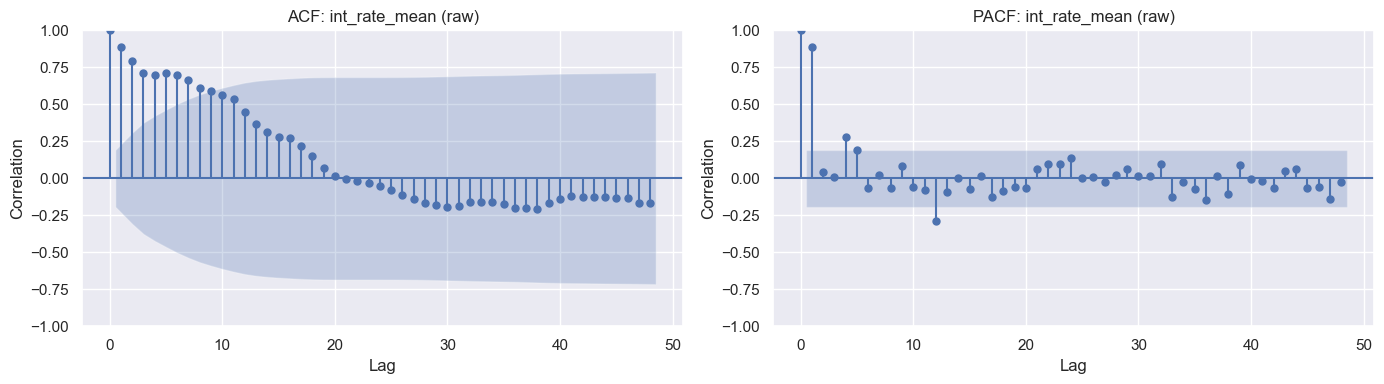

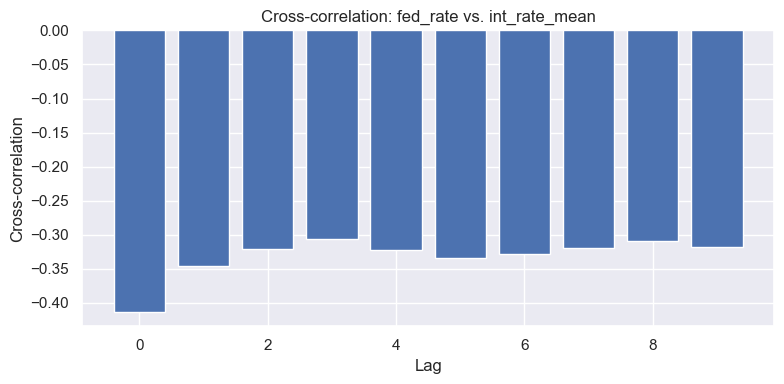

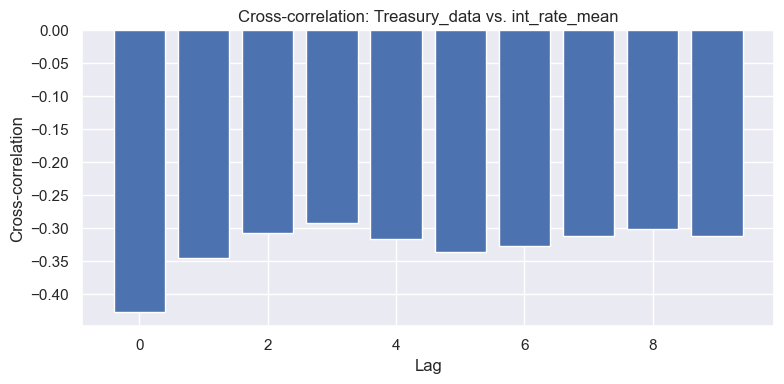

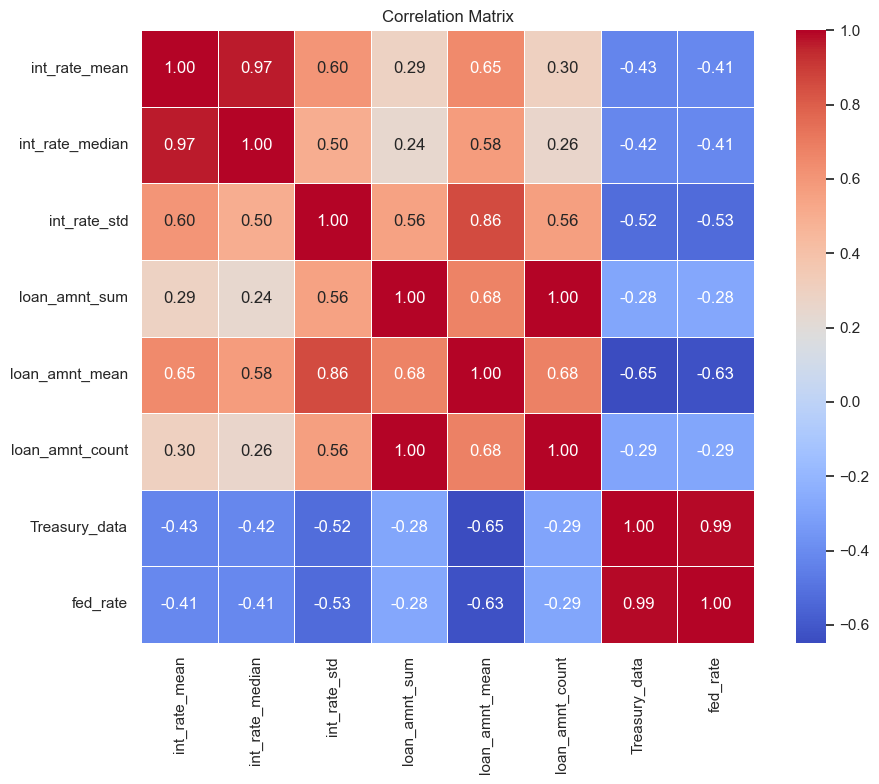

In [84]:
plot_series_diagnostics(train[TARGET_COL], f"{TARGET_COL} (raw)")

if OPTIONAL_DRIVER_COL in train.columns:
    plot_cross_correlation(
        train[TARGET_COL],
        train[OPTIONAL_DRIVER_COL],
        f"Cross-correlation: {OPTIONAL_DRIVER_COL} vs. {TARGET_COL}",
    )

plot_cross_correlation(
    train[TARGET_COL],
    train[TREASURY_COL],
    f"Cross-correlation: {TREASURY_COL} vs. {TARGET_COL}",
)

plot_correlation_heatmap(train)

**Conclusion** 

The diagnostic tests indicate that **`Treasury_data`** and **`fed_rate`** are highly correlated, suggesting that one of them can be removed to avoid multicollinearity. 

Additionally, the analysis shows that the target variable exhibits its strongest correlation with the **zeroth and first lag of `Treasury_data`**, we will however drop the zeroth lag to avoid temporal leakage.

## 3. Time-series decomposition and stationarity checks

Before fitting forecasting models, the target  **`int_rate_mean`** and the external regressor **`Treasury_data`** are examined for trend, seasonality, and stationarity. The transformations defined here are reused later so that model inputs are built from a single consistent preprocessing pipeline.

In [85]:
def run_adf_test(series: pd.Series, name: str) -> None:
    """Print Augmented Dickey-Fuller test results for a series."""
    clean_series = series.dropna()
    statistic, p_value, _, _, critical_values, _ = adfuller(clean_series, autolag="AIC")

    print(f"ADF test: {name}")
    print(f"  Statistic: {statistic:.4f}")
    print(f"  p-value:   {p_value:.4f}")
    print("  Critical values:")
    for level, value in critical_values.items():
        print(f"    {level}: {value:.4f}")

    conclusion = "stationary" if p_value <= 0.05 else "non-stationary"
    print(f"  Conclusion: {conclusion}\n")


def plot_stl_decomposition(series: pd.Series, title: str, period: int = SEASONAL_PERIOD) -> None:
    """Run STL decomposition and report the seasonal range."""
    decomposition = STL(series.dropna(), period=period, robust=True).fit()
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

    seasonal_min = decomposition.seasonal.min()
    seasonal_max = decomposition.seasonal.max()
    print(f"{title} seasonal range: {seasonal_min:.4f} to {seasonal_max:.4f}")


def compute_positive_shift(series: pd.Series, buffer: float = 0.0) -> float:
    """Return the smallest nonnegative shift needed to make a series positive."""
    minimum = series.min()
    return max(0.0, -minimum + buffer)

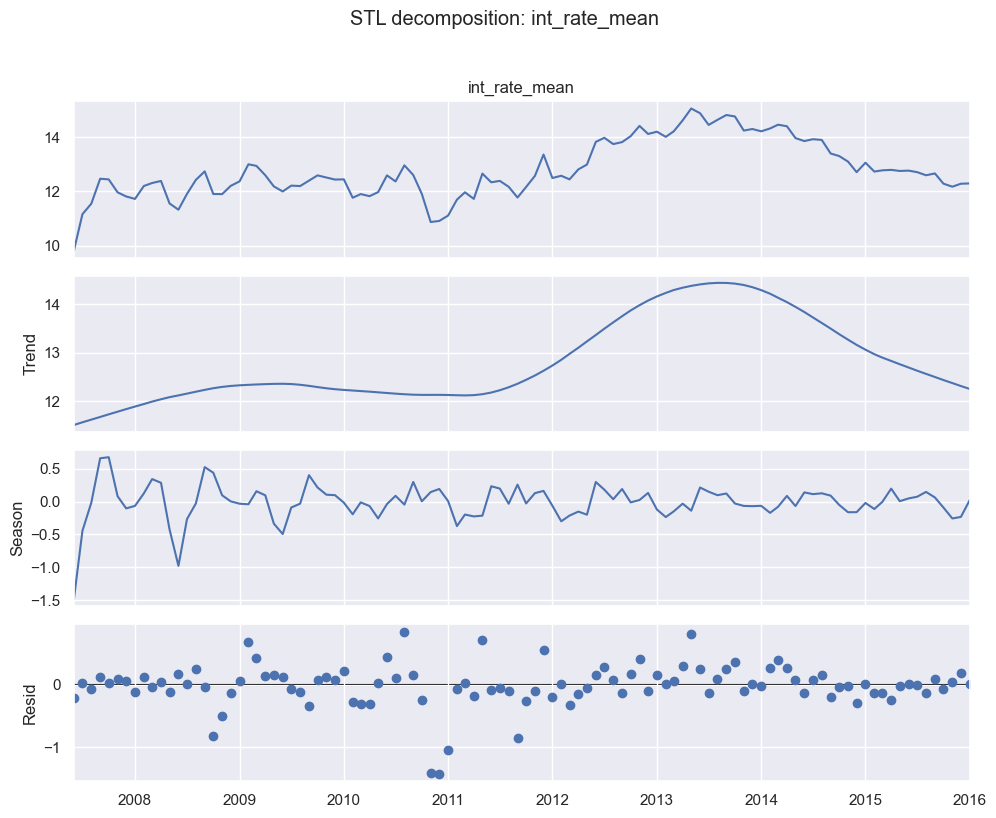

STL decomposition: int_rate_mean seasonal range: -1.4897 to 0.6788


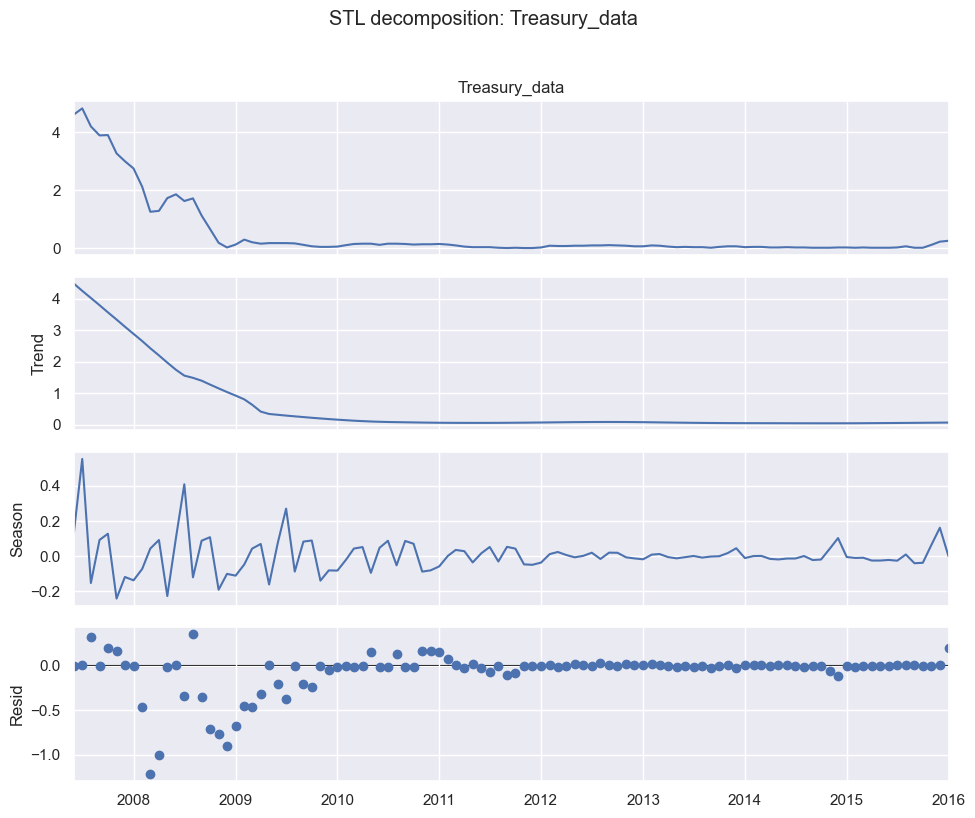

STL decomposition: Treasury_data seasonal range: -0.2415 to 0.5535


In [86]:
# The time-indexed frame is used for decomposition, transformations, and
# later reconstruction of forecasts back to the original scale.
train_ts = (
    train[[DATE_COL, TARGET_COL, TREASURY_COL]]
    .copy()
    .set_index(DATE_COL)
    .sort_index()
)

plot_stl_decomposition(train_ts[TARGET_COL], f"STL decomposition: {TARGET_COL}")
plot_stl_decomposition(train_ts[TREASURY_COL], f"STL decomposition: {TREASURY_COL}")

In [87]:
# Apply a stable sequence of transformations that will be reused later:
# Box-Cox for the target, then differencing; log-difference for treasury.
TARGET_BOXCOX_SHIFT = compute_positive_shift(train_ts[TARGET_COL])
target_for_boxcox = train_ts[TARGET_COL] + TARGET_BOXCOX_SHIFT

train_ts["target_boxcox"], TARGET_BOXCOX_LAMBDA = boxcox(target_for_boxcox)
train_ts["target_diff1"] = train_ts["target_boxcox"].diff(1)
train_ts["target_diff2"] = train_ts["target_boxcox"].diff(1).diff(1)

TREASURY_LOG_SHIFT = compute_positive_shift(train_ts[TREASURY_COL], buffer=0.1)
train_ts["treasury_shifted"] = train_ts[TREASURY_COL] + TREASURY_LOG_SHIFT
train_ts["treasury_log"] = np.log(train_ts["treasury_shifted"])
train_ts["treasury_log_diff"] = train_ts["treasury_log"].diff(1)

print(f"Target Box-Cox lambda: {TARGET_BOXCOX_LAMBDA:.6f}")
print(f"Target Box-Cox shift:  {TARGET_BOXCOX_SHIFT:.6f}")
print(f"Treasury log shift:    {TREASURY_LOG_SHIFT:.6f}")

Target Box-Cox lambda: -0.177860
Target Box-Cox shift:  0.000000
Treasury log shift:    0.090000


In [88]:
run_adf_test(train_ts[TARGET_COL], "Raw target series")
run_adf_test(train_ts["target_diff1"], "Box-Cox target, first difference")
run_adf_test(train_ts["target_diff2"], "Box-Cox target, second difference")
run_adf_test(train_ts[TREASURY_COL], "Raw treasury series")
run_adf_test(train_ts["treasury_log_diff"], "Log-transformed treasury series, first difference")

ADF test: Raw target series
  Statistic: -1.9891
  p-value:   0.2914
  Critical values:
    1%: -3.5035
    5%: -2.8935
    10%: -2.5838
  Conclusion: non-stationary

ADF test: Box-Cox target, first difference
  Statistic: -1.7512
  p-value:   0.4049
  Critical values:
    1%: -3.5043
    5%: -2.8939
    10%: -2.5840
  Conclusion: non-stationary

ADF test: Box-Cox target, second difference
  Statistic: -8.1687
  p-value:   0.0000
  Critical values:
    1%: -3.5035
    5%: -2.8935
    10%: -2.5838
  Conclusion: stationary

ADF test: Raw treasury series
  Statistic: -5.0716
  p-value:   0.0000
  Critical values:
    1%: -3.5052
    5%: -2.8942
    10%: -2.5842
  Conclusion: stationary

ADF test: Log-transformed treasury series, first difference
  Statistic: -8.1772
  p-value:   0.0000
  Critical values:
    1%: -3.4968
    5%: -2.8906
    10%: -2.5823
  Conclusion: stationary



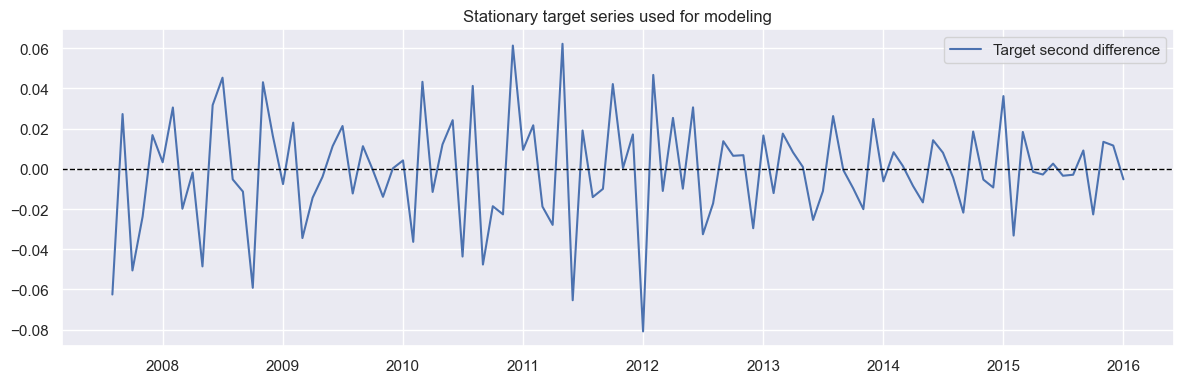

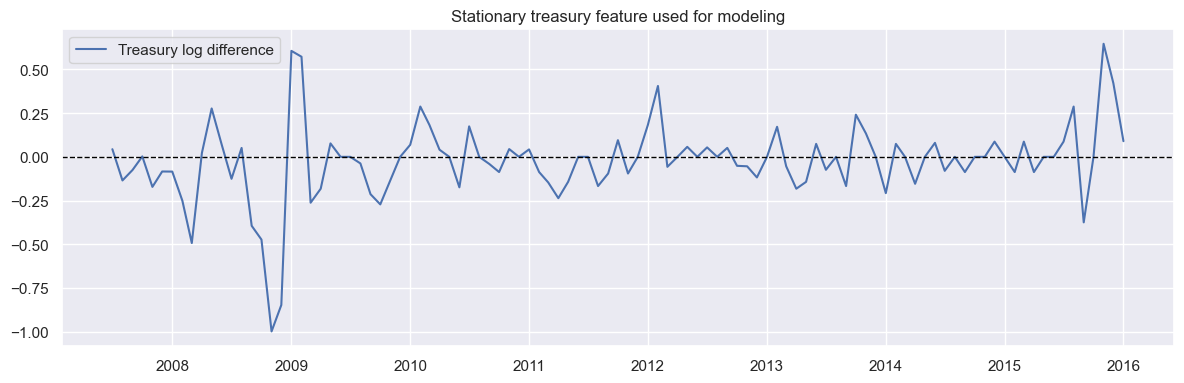

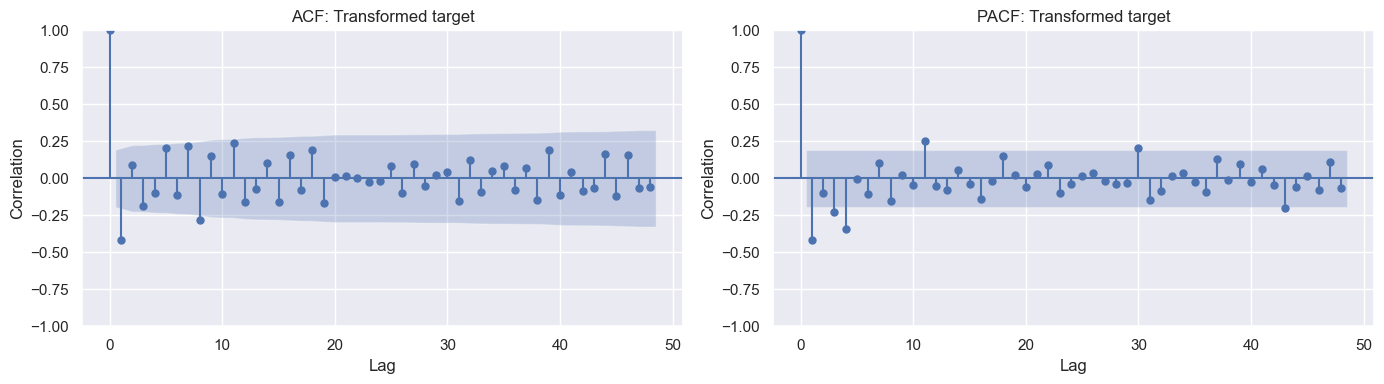

In [89]:
plt.figure(figsize=(12, 4))
plt.plot(train_ts.index, train_ts["target_diff2"], label="Target second difference")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Stationary target series used for modeling")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(train_ts.index, train_ts["treasury_log_diff"], label="Treasury log difference")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Stationary treasury feature used for modeling")
plt.legend()
plt.tight_layout()
plt.show()

plot_series_diagnostics(train_ts["target_diff2"], "Transformed target")

**Conclusion**

We first apply a **Box–Cox transformation** to the target variable **`int_rate_mean`**. 
A first difference does not produce a stationary time series, so we apply **second differencing** to achieve stationarity.

For **`Treasury_data`**, the **ADF test** suggests stationarity. However, visual inspection of the time series indicates non-stationary behavior. Therefore, we apply a **log transformation followed by differencing** to stabilize the series.

The **PACF analysis** indicates that the most important lagged values of the target variable occur at **lags 1, 2, and 4**. Although **lag 11** also appears significant, we exclude it because earlier **seasonal decomposition** showed that the seasonal component of the series is minimal.

## 4. Modeling frame and cross-validation setup

This section assembles the supervised learning table used by the forecasting models. It also defines the rolling one-step-ahead validation scheme. First we define the variables that would be important from now, keeping in mind the results from the previous step.

In [90]:
# Lag structure used to build the feature table.
TARGET_LAGS = [1, 3, 4]
TREASURY_LAG = 1 

# Rolling cross-validation design.
CV_SPLITS = 20
CV_TEST_SIZE = 1 

TARGET_DIFF2_COL = "target_diff2"




In [91]:
def create_modeling_frame(ts_frame: pd.DataFrame) -> pd.DataFrame:
    """Construct the supervised learning table used by all forecasting models."""
    frame = pd.DataFrame(index=ts_frame.index)

    frame[TARGET_DIFF2_COL] = ts_frame["target_diff2"]

    # Lagged transformed target values are the main autoregressive features.
    for lag in TARGET_LAGS:
        frame[f"target_lag_{lag}"] = frame[TARGET_DIFF2_COL].shift(lag)

    # The treasury regressor enters with a one-step lag.
    frame["treasury_lag_1"] = ts_frame["treasury_log_diff"].shift(TREASURY_LAG)

    # These anchor values allow predictions on the differenced Box-Cox scale
    # to be reconstructed back to the original target scale.
    frame["prev_diff1"] = ts_frame["target_diff1"].shift(1)
    frame["prev_boxcox"] = ts_frame["target_boxcox"].shift(1)

    return frame.dropna()


train_model = create_modeling_frame(train_ts)

FEATURE_COLS = [f"target_lag_{lag}" for lag in TARGET_LAGS] + ["treasury_lag_1"]
SEQUENCE_FEATURE_COLS = [TARGET_DIFF2_COL, "treasury_lag_1"]

tscv = TimeSeriesSplit(n_splits=CV_SPLITS, test_size=CV_TEST_SIZE)

print(f"Modeling frame shape: {train_model.shape}")
print("\nFeature columns:")
print(FEATURE_COLS)
print("\nSample rows:")
train_model.head()

Modeling frame shape: (98, 7)

Feature columns:
['target_lag_1', 'target_lag_3', 'target_lag_4', 'treasury_lag_1']

Sample rows:


,target_diff2,target_lag_1,target_lag_3,target_lag_4,treasury_lag_1,prev_diff1,prev_boxcox
Month,,,,,,,
2007-12-01,0.016794,-0.023748,0.027260,-0.062510,-0.171850,-0.025016,2.006458
2008-01-01,0.003281,0.016794,-0.050546,0.027260,-0.083770,-0.008223,1.998235
2008-02-01,0.030522,0.003281,-0.023748,-0.050546,-0.084367,-0.004941,1.993294
2008-03-01,-0.019838,0.030522,0.016794,-0.023748,-0.250812,0.025580,2.018874
2008-04-01,-0.001845,-0.019838,0.003281,0.016794,-0.492888,0.005743,2.024617


In [92]:
# Record the train/test boundaries for each rolling split so the validation
# design is explicit before model fitting begins.
fold_schedule = []

for fold, (train_index, test_index) in enumerate(tscv.split(train_model), start=1):
    fold_schedule.append(
        {
            "fold": fold,
            "train_end": train_model.index[train_index[-1]].date(),
            "test_date": train_model.index[test_index[0]].date(),
            "train_size": len(train_index),
        }
    )

pd.DataFrame(fold_schedule)

,fold,train_end,test_date,train_size
0,1,2014-05-01,2014-06-01,78
1,2,2014-06-01,2014-07-01,79
2,3,2014-07-01,2014-08-01,80
3,4,2014-08-01,2014-09-01,81
4,5,2014-09-01,2014-10-01,82
5,6,2014-10-01,2014-11-01,83
6,7,2014-11-01,2014-12-01,84
7,8,2014-12-01,2015-01-01,85
8,9,2015-01-01,2015-02-01,86
9,10,2015-02-01,2015-03-01,87


## 5. Shared evaluation utilities

All models ultimately predict on a transformed scale, so these helper functions standardize how predictions are mapped back to the original target units and how forecast errors are summarized. We also define the constants for all the models.

In [93]:
def inverse_boxcox_to_original(boxcox_value: float, boxcox_lambda: float, boxcox_shift: float = 0.0) -> float:
    """Invert the Box-Cox transformation and remove any positive shift."""
    return inv_boxcox(boxcox_value, boxcox_lambda) - boxcox_shift


def reconstruct_prediction(pred_diff2: float, anchor_row: pd.Series) -> float:
    """Map a second-difference prediction back to the original target scale."""
    pred_boxcox = pred_diff2 + anchor_row["prev_diff1"] + anchor_row["prev_boxcox"]
    return inverse_boxcox_to_original(pred_boxcox, TARGET_BOXCOX_LAMBDA, TARGET_BOXCOX_SHIFT)


def summarize_forecasts(results: pd.DataFrame) -> dict:
    """Return standard error metrics for a forecast table."""
    return {
        "RMSE": np.sqrt(mean_squared_error(results["actual"], results["prediction"])),
        "MAE": mean_absolute_error(results["actual"], results["prediction"]),
        "n_forecasts": len(results),
    }


def run_one_step_cv(frame: pd.DataFrame, splitter: TimeSeriesSplit, predict_diff2_fn) -> pd.DataFrame:
    """Run rolling one-step-ahead evaluation for a model that predicts target_diff2."""
    records = []

    for fold, (train_index, test_index) in enumerate(splitter.split(frame), start=1):
        train_df = frame.iloc[train_index]
        test_df = frame.iloc[test_index]

        pred_diff2 = predict_diff2_fn(train_df, test_df)
        anchor_row = test_df.iloc[0]
        prediction = reconstruct_prediction(pred_diff2, anchor_row)
        actual = train_ts.loc[test_df.index[0], TARGET_COL]

        records.append(
            {
                "fold": fold,
                "date": test_df.index[0],
                "actual": actual,
                "prediction": prediction,
                "abs_error": abs(actual - prediction),
            }
        )

    return pd.DataFrame(records)

In [94]:
# Search grids for classical machine learning models.
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
RF_N_ESTIMATORS = [50, 100]
RF_MAX_DEPTHS = [3, 5, None]
SARIMAX_ORDERS = list(itertools.product([2, 3, 4], [0], [0, 1]))

# Trial budgets for Optuna-based experiments.
MLP_TRIALS = 50
RNN_TRIALS = 30
CNN_TRIALS = 30

## 6. Baseline forecasts

These simple benchmarks provide a reference point for the more complex models. Any advanced model should improve on these baselines to justify its added complexity.

In [95]:
def evaluate_baseline_models(frame: pd.DataFrame, splitter: TimeSeriesSplit) -> pd.DataFrame:
    """Evaluate simple reference forecasts under the same rolling split design."""
    records = []

    for fold, (train_index, test_index) in enumerate(splitter.split(frame), start=1):
        last_train_date = frame.index[train_index[-1]]
        test_date = frame.index[test_index[0]]

        actual = train_ts.loc[test_date, TARGET_COL]
        naive_pred = train_ts.loc[last_train_date, TARGET_COL]
        rolling_avg4_pred = train_ts.loc[:last_train_date, TARGET_COL].tail(4).mean()

        records.extend(
            [
                {"model": "Naive", "fold": fold, "date": test_date, "actual": actual, "prediction": naive_pred},
                {"model": "RollingAvg4", "fold": fold, "date": test_date, "actual": actual, "prediction": rolling_avg4_pred},
            ]
        )

    return pd.DataFrame(records)


baseline_predictions = evaluate_baseline_models(train_model, tscv)
baseline_summary = (
    baseline_predictions.groupby("model")
    .apply(lambda df: pd.Series(summarize_forecasts(df)))
    .reset_index()
    .sort_values("RMSE")
)

baseline_summary

,model,RMSE,MAE,n_forecasts
0,Naive,0.210555,0.151338,20.0
1,RollingAvg4,0.318288,0.245548,20.0


## 7. Ridge regression

Ridge regression is used as a regularized linear benchmark on the engineered lag features. The hyperparameter search is intentionally small  because the dataset is limited in size.

In [96]:
def ridge_predict_diff2(train_df: pd.DataFrame, test_df: pd.DataFrame, alpha: float) -> float:
    """Fit Ridge regression on the lag features and predict the next target_diff2 value."""
    model = Ridge(alpha=alpha)
    model.fit(train_df[FEATURE_COLS], train_df[TARGET_DIFF2_COL])
    return model.predict(test_df[FEATURE_COLS])[0]


ridge_search_results = []

for alpha in RIDGE_ALPHAS:
    cv_results = run_one_step_cv(
        train_model,
        tscv,
        lambda train_df, test_df, alpha=alpha: ridge_predict_diff2(train_df, test_df, alpha),
    )
    metrics = summarize_forecasts(cv_results)
    ridge_search_results.append({"alpha": alpha, **metrics})

ridge_search_results = pd.DataFrame(ridge_search_results).sort_values("RMSE")
best_ridge = ridge_search_results.iloc[0].to_dict()

ridge_search_results

,alpha,RMSE,MAE,n_forecasts
0,0.01,0.271028,0.214878,20
1,0.10,0.286733,0.224645,20
2,1.00,0.310583,0.240852,20
3,10.00,0.318106,0.248049,20
4,100.00,0.320976,0.250362,20


## 8. SARIMAX with treasury as an exogenous regressor

This model combines autoregressive structure with an external treasury-based regressor. It serves as the main classical time-series model in the comparison.

In [97]:
def sarimax_predict_diff2(train_df: pd.DataFrame, test_df: pd.DataFrame, order: tuple[int, int, int]) -> float:
    """Fit SARIMAX on the transformed target with treasury as an exogenous input."""
    model = SARIMAX(
        endog=train_df[TARGET_DIFF2_COL],
        exog=train_df[["treasury_lag_1"]],
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    return fitted.forecast(steps=1, exog=test_df[["treasury_lag_1"]]).iloc[0]


sarimax_search_results = []

for order in SARIMAX_ORDERS:
    try:
        cv_results = run_one_step_cv(
            train_model,
            tscv,
            lambda train_df, test_df, order=order: sarimax_predict_diff2(train_df, test_df, order),
        )
        metrics = summarize_forecasts(cv_results)
        sarimax_search_results.append({"order": order, **metrics})
    except Exception:
        # Some parameter combinations fail to converge on short samples.
        continue

sarimax_search_results = pd.DataFrame(sarimax_search_results).sort_values("RMSE")
best_sarimax = sarimax_search_results.iloc[0].to_dict()

sarimax_search_results

,order,RMSE,MAE,n_forecasts
1,"(2, 0, 1)",0.190637,0.138230,20
4,"(4, 0, 0)",0.237060,0.183991,20
0,"(2, 0, 0)",0.240664,0.176198,20
2,"(3, 0, 0)",0.257932,0.205860,20
5,"(4, 0, 1)",0.258673,0.193726,20
3,"(3, 0, 1)",0.261155,0.198490,20


## 9. Random forest

The random forest model tests whether a nonlinear tree-based learner can improve on the linear benchmark while still using the same lagged feature table.

In [98]:
def random_forest_predict_diff2(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    n_estimators: int,
    max_depth: int | None,
) -> float:
    """Fit a random forest on the lag features and predict the next target_diff2 value."""
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=SEED,
    )
    model.fit(train_df[FEATURE_COLS], train_df[TARGET_DIFF2_COL])
    return model.predict(test_df[FEATURE_COLS])[0]


rf_search_results = []

for n_estimators, max_depth in itertools.product(RF_N_ESTIMATORS, RF_MAX_DEPTHS):
    cv_results = run_one_step_cv(
        train_model,
        tscv,
        lambda train_df, test_df, n_estimators=n_estimators, max_depth=max_depth:
            random_forest_predict_diff2(train_df, test_df, n_estimators, max_depth),
    )
    metrics = summarize_forecasts(cv_results)
    rf_search_results.append(
        {"n_estimators": n_estimators, "max_depth": max_depth, **metrics}
    )

rf_search_results = pd.DataFrame(rf_search_results).sort_values("RMSE")
best_rf = rf_search_results.iloc[0].to_dict()

rf_search_results

,n_estimators,max_depth,RMSE,MAE,n_forecasts
3,100,3.0,0.285610,0.213652,20
4,100,5.0,0.299642,0.227054,20
0,50,3.0,0.303190,0.221881,20
1,50,5.0,0.311981,0.233446,20
5,100,NaN,0.313054,0.232036,20
2,50,NaN,0.320804,0.240080,20


## 10. Neural network helper classes and utilities

The helper functions and lightweight PyTorch modules in this section are shared across the MLP, recurrent, and CNN experiments. 

In [99]:
def clone_state_dict(model: nn.Module) -> dict:
    """Create a detached copy of a model state for early stopping."""
    return {name: tensor.detach().clone() for name, tensor in model.state_dict().items()}


def create_sequences(X_data: np.ndarray, y_data: np.ndarray, seq_length: int) -> tuple[np.ndarray, np.ndarray]:
    """Convert tabular arrays into sliding windows for sequence models."""
    X_seq, y_seq = [], []
    for start_idx in range(len(X_data) - seq_length):
        end_idx = start_idx + seq_length
        X_seq.append(X_data[start_idx:end_idx])
        y_seq.append(y_data[end_idx])
    return np.array(X_seq), np.array(y_seq)


def train_torch_model(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    optimizer: optim.Optimizer,
    loss_fn,
    max_epochs: int,
    X_val: torch.Tensor | None = None,
    y_val: torch.Tensor | None = None,
    patience: int | None = None,
) -> nn.Module:
    """Train a PyTorch model with optional early stopping on a validation set."""
    best_state = None
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_output = model(X_train)
        train_loss = loss_fn(train_output, y_train)
        train_loss.backward()
        optimizer.step()

        if X_val is None or y_val is None:
            continue

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = loss_fn(val_output, y_val).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            best_state = clone_state_dict(model)
        else:
            epochs_without_improvement += 1
            if patience is not None and epochs_without_improvement >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


class DynamicMLP(nn.Module):
    """Small feed-forward network for the lag-feature baseline."""

    def __init__(self, input_dim: int, hidden_dim: int, dropout_prob: float):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class TinyRNN(nn.Module):
    """Single-layer GRU or LSTM followed by a linear output head."""

    def __init__(self, input_dim: int, hidden_dim: int, rnn_type: str):
        super().__init__()
        if rnn_type == "GRU":
            self.recurrent = nn.GRU(input_dim, hidden_dim, num_layers=1, batch_first=True)
            self.is_lstm = False
        else:
            self.recurrent = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True)
            self.is_lstm = True
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, hidden = self.recurrent(x)
        if self.is_lstm:
            hidden = hidden[0]
        last_hidden = hidden[-1]
        return self.output(last_hidden)


class Tiny1DCNN(nn.Module):
    """Compact one-dimensional CNN for short temporal windows."""

    def __init__(self, input_dim: int, num_filters: int, kernel_size: int, seq_length: int):
        super().__init__()
        conv_output_length = seq_length - kernel_size + 1
        self.conv = nn.Conv1d(input_dim, num_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(num_filters * conv_output_length, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.transpose(1, 2)
        x = self.relu(self.conv(x))
        x = x.reshape(x.size(0), -1)
        return self.output(x)

## 11. MLP tuned with Optuna

This section tunes a compact multilayer perceptron on the tabular lag features. Because the sample size is small, the network and search space are small to reduce overfitting risk.

In [100]:
def mlp_objective(trial: optuna.Trial) -> float:
    """Optuna objective for a compact MLP evaluated by rolling MAE."""
    hidden_dim = trial.suggest_categorical("hidden_dim", [4, 8, 16, 24])
    dropout_prob = trial.suggest_float("dropout", 0.1, 0.6)
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    fold_records = []

    for fold, (train_index, test_index) in enumerate(tscv.split(train_model), start=1):
        train_df = train_model.iloc[train_index]
        test_df = train_model.iloc[test_index]

        # Standardize the tabular features within each fold to avoid leakage.
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_df[FEATURE_COLS])
        X_test = scaler.transform(test_df[FEATURE_COLS])

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(train_df[TARGET_DIFF2_COL].to_numpy().reshape(-1, 1), dtype=torch.float32)
        X_test_t = torch.tensor(X_test, dtype=torch.float32)

        model = DynamicMLP(input_dim=X_train_t.shape[1], hidden_dim=hidden_dim, dropout_prob=dropout_prob)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.MSELoss()

        model = train_torch_model(
            model=model,
            X_train=X_train_t,
            y_train=y_train_t,
            optimizer=optimizer,
            loss_fn=loss_fn,
            max_epochs=100,
        )

        model.eval()
        with torch.no_grad():
            pred_diff2 = model(X_test_t).item()

        prediction = reconstruct_prediction(pred_diff2, test_df.iloc[0])
        actual = train_ts.loc[test_df.index[0], TARGET_COL]

        fold_records.append(
            {
                "fold": fold,
                "date": test_df.index[0],
                "actual": float(actual),
                "prediction": float(prediction),
            }
        )

    metrics = summarize_forecasts(pd.DataFrame(fold_records))
    trial.set_user_attr("rolling_val_rmse", float(metrics["RMSE"]))
    trial.set_user_attr("rolling_val_mae", float(metrics["MAE"]))
    trial.set_user_attr("n_forecasts", int(metrics["n_forecasts"]))

    return float(metrics["RMSE"])


mlp_study = optuna.create_study(direction="minimize")
mlp_study.optimize(mlp_objective, n_trials=MLP_TRIALS)

best_mlp = {
    "params": mlp_study.best_params,
    "rolling_val_rmse": float(mlp_study.best_trial.user_attrs["rolling_val_rmse"]),
    "rolling_val_mae": float(mlp_study.best_trial.user_attrs["rolling_val_mae"]),
    "n_forecasts": int(mlp_study.best_trial.user_attrs["n_forecasts"]),
}

best_mlp

{'params': {'hidden_dim': 16,
  'dropout': 0.3986286642748129,
  'lr': 0.0048549115345804476},
 'rolling_val_rmse': 0.2635008149499565,
 'rolling_val_mae': 0.19537885379693049,
 'n_forecasts': 20}

## 12. Recurrent model tuned with Optuna

The recurrent experiment evaluates whether short sequential windows provide an advantage over the tabular lag representation. Each fold includes an internal validation split for early stopping.

In [101]:
def rnn_objective(trial: optuna.Trial) -> float:
    """Optuna objective for GRU/LSTM models evaluated by rolling MAE."""
    rnn_type = trial.suggest_categorical("rnn_type", ["GRU", "LSTM"])
    seq_length = trial.suggest_int("seq_length", 3, 5)
    hidden_dim = trial.suggest_int("hidden_dim", 4, 12, step=4)
    learning_rate = trial.suggest_float("lr", 1e-3, 5e-2, log=True)

    fold_records = []

    for fold, (train_index, test_index) in enumerate(tscv.split(train_model), start=1):
        train_full = train_model.iloc[train_index]
        test_df = train_model.iloc[test_index]

        if len(train_full) <= seq_length + 2:
            return float("inf")

        # Reserve the tail of the training window for fold-specific validation.
        split_idx = int(len(train_full) * 0.85)
        train_df = train_full.iloc[:split_idx]
        val_df = train_full.iloc[split_idx:]

        if len(train_df) <= seq_length or len(val_df) <= seq_length:
            return float("inf")

        X_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train = X_scaler.fit_transform(train_df[SEQUENCE_FEATURE_COLS])
        y_train = y_scaler.fit_transform(train_df[[TARGET_DIFF2_COL]])
        X_val = X_scaler.transform(val_df[SEQUENCE_FEATURE_COLS])
        y_val = y_scaler.transform(val_df[[TARGET_DIFF2_COL]])

        X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
        X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_length)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            return float("inf")

        X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
        y_train_t = torch.tensor(y_train_seq.reshape(-1, 1), dtype=torch.float32)
        X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
        y_val_t = torch.tensor(y_val_seq.reshape(-1, 1), dtype=torch.float32)

        model = TinyRNN(input_dim=X_train_t.shape[2], hidden_dim=hidden_dim, rnn_type=rnn_type)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.HuberLoss()

        model = train_torch_model(
            model=model,
            X_train=X_train_t,
            y_train=y_train_t,
            X_val=X_val_t,
            y_val=y_val_t,
            optimizer=optimizer,
            loss_fn=loss_fn,
            max_epochs=150,
            patience=15,
        )

        # Forecast the next point from the most recent sequence in the fold.
        last_window = train_full[SEQUENCE_FEATURE_COLS].iloc[-seq_length:]
        X_test = X_scaler.transform(last_window)
        X_test_t = torch.tensor(X_test.reshape(1, seq_length, -1), dtype=torch.float32)

        model.eval()
        with torch.no_grad():
            pred_scaled = model(X_test_t).numpy().reshape(-1, 1)

        pred_diff2 = y_scaler.inverse_transform(pred_scaled)[0, 0]
        prediction = reconstruct_prediction(pred_diff2, test_df.iloc[0])
        actual = train_ts.loc[test_df.index[0], TARGET_COL]

        fold_records.append(
            {
                "fold": fold,
                "date": test_df.index[0],
                "actual": float(actual),
                "prediction": float(prediction),
            }
        )

    metrics = summarize_forecasts(pd.DataFrame(fold_records))
    trial.set_user_attr("rolling_val_rmse", float(metrics["RMSE"]))
    trial.set_user_attr("rolling_val_mae", float(metrics["MAE"]))
    trial.set_user_attr("n_forecasts", int(metrics["n_forecasts"]))

    return float(metrics["RMSE"])


rnn_study = optuna.create_study(direction="minimize")
rnn_study.optimize(rnn_objective, n_trials=RNN_TRIALS)

best_rnn = {
    "params": rnn_study.best_params,
    "rolling_val_rmse": float(rnn_study.best_trial.user_attrs["rolling_val_rmse"]),
    "rolling_val_mae": float(rnn_study.best_trial.user_attrs["rolling_val_mae"]),
    "n_forecasts": int(rnn_study.best_trial.user_attrs["n_forecasts"]),
}

best_rnn

{'params': {'rnn_type': 'GRU',
  'seq_length': 5,
  'hidden_dim': 12,
  'lr': 0.013563277312685059},
 'rolling_val_rmse': 0.23307739594085952,
 'rolling_val_mae': 0.18861284865485609,
 'n_forecasts': 20}

## 13. One-dimensional CNN tuned with Optuna

The CNN experiment applies convolution over short temporal windows of the transformed features. As with the recurrent model, the architecture is intentionally small to match the scale of the dataset.

In [102]:
def cnn_objective(trial: optuna.Trial) -> float:
    """Optuna objective for a compact 1D CNN evaluated by rolling MAE."""
    seq_length = trial.suggest_int("seq_length", 3, 4)
    kernel_size = trial.suggest_int("kernel_size", 2, 3)
    num_filters = trial.suggest_categorical("num_filters", [4, 8, 12])
    learning_rate = trial.suggest_float("lr", 1e-3, 5e-2, log=True)

    if kernel_size > seq_length:
        return float("inf")

    fold_records = []

    for fold, (train_index, test_index) in enumerate(tscv.split(train_model), start=1):
        train_full = train_model.iloc[train_index]
        test_df = train_model.iloc[test_index]

        if len(train_full) <= seq_length + 2:
            return float("inf")

        # Reserve the tail of the training window for fold-specific validation.
        split_idx = int(len(train_full) * 0.85)
        train_df = train_full.iloc[:split_idx]
        val_df = train_full.iloc[split_idx:]

        if len(train_df) <= seq_length or len(val_df) <= seq_length:
            return float("inf")

        X_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train = X_scaler.fit_transform(train_df[SEQUENCE_FEATURE_COLS])
        y_train = y_scaler.fit_transform(train_df[[TARGET_DIFF2_COL]])
        X_val = X_scaler.transform(val_df[SEQUENCE_FEATURE_COLS])
        y_val = y_scaler.transform(val_df[[TARGET_DIFF2_COL]])

        X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
        X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_length)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            return float("inf")

        X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
        y_train_t = torch.tensor(y_train_seq.reshape(-1, 1), dtype=torch.float32)
        X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
        y_val_t = torch.tensor(y_val_seq.reshape(-1, 1), dtype=torch.float32)

        model = Tiny1DCNN(
            input_dim=X_train_t.shape[2],
            num_filters=num_filters,
            kernel_size=kernel_size,
            seq_length=seq_length,
        )
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = nn.HuberLoss()

        model = train_torch_model(
            model=model,
            X_train=X_train_t,
            y_train=y_train_t,
            X_val=X_val_t,
            y_val=y_val_t,
            optimizer=optimizer,
            loss_fn=loss_fn,
            max_epochs=150,
            patience=15,
        )

        # Forecast the next point from the most recent sequence in the fold.
        last_window = train_full[SEQUENCE_FEATURE_COLS].iloc[-seq_length:]
        X_test = X_scaler.transform(last_window)
        X_test_t = torch.tensor(X_test.reshape(1, seq_length, -1), dtype=torch.float32)

        model.eval()
        with torch.no_grad():
            pred_scaled = model(X_test_t).numpy().reshape(-1, 1)

        pred_diff2 = y_scaler.inverse_transform(pred_scaled)[0, 0]
        prediction = reconstruct_prediction(pred_diff2, test_df.iloc[0])
        actual = train_ts.loc[test_df.index[0], TARGET_COL]

        fold_records.append(
            {
                "fold": fold,
                "date": test_df.index[0],
                "actual": float(actual),
                "prediction": float(prediction),
            }
        )

    metrics = summarize_forecasts(pd.DataFrame(fold_records))
    trial.set_user_attr("rolling_val_rmse", float(metrics["RMSE"]))
    trial.set_user_attr("rolling_val_mae", float(metrics["MAE"]))
    trial.set_user_attr("n_forecasts", int(metrics["n_forecasts"]))

    return float(metrics["RMSE"])


cnn_study = optuna.create_study(direction="minimize")
cnn_study.optimize(cnn_objective, n_trials=CNN_TRIALS)

best_cnn = {
    "params": cnn_study.best_params,
    "rolling_val_rmse": float(cnn_study.best_trial.user_attrs["rolling_val_rmse"]),
    "rolling_val_mae": float(cnn_study.best_trial.user_attrs["rolling_val_mae"]),
    "n_forecasts": int(cnn_study.best_trial.user_attrs["n_forecasts"]),
}

best_cnn

{'params': {'seq_length': 3,
  'kernel_size': 2,
  'num_filters': 8,
  'lr': 0.01171124222451931},
 'rolling_val_rmse': 0.2655930769965288,
 'rolling_val_mae': 0.1993911579042728,
 'n_forecasts': 20}

## 14. Final performance summary

The table below compares the models that produce directly comparable forecast errors on the original target scale. The Optuna-based deep learning sections report their best tuning objective separately because their internal training loops are optimized through nested fitting procedures.

In [103]:
# Only models evaluated through the shared reconstruction pipeline are placed
# in the main comparison table below.
comparable_models = pd.DataFrame(
    [
        {"model": "Naive", **baseline_summary[baseline_summary["model"] == "Naive"].iloc[0].drop("model").to_dict()},
        {"model": "RollingAvg4", **baseline_summary[baseline_summary["model"] == "RollingAvg4"].iloc[0].drop("model").to_dict()},
        {"model": "Ridge", **{k: best_ridge[k] for k in ["RMSE", "MAE", "n_forecasts"]}},
        {"model": "SARIMAX", **{k: best_sarimax[k] for k in ["RMSE", "MAE", "n_forecasts"]}},
        {"model": "RandomForest", **{k: best_rf[k] for k in ["RMSE", "MAE", "n_forecasts"]}},
    ]
).sort_values("RMSE")

comparable_models

,model,RMSE,MAE,n_forecasts
3,SARIMAX,0.190637,0.138230,20.0
0,Naive,0.210555,0.151338,20.0
2,Ridge,0.271028,0.214878,20.0
4,RandomForest,0.285610,0.213652,20.0
1,RollingAvg4,0.318288,0.245548,20.0


In [104]:
# Collect the tuned deep learning results in one table so the selected
# hyperparameters and validation scores can be compared side by side.
# Summarize the tuned deep learning models with both rolling validation MAE
# and RMSE on the reconstructed prediction scale.
deep_learning_summary = (
    pd.DataFrame(
        [
            {
                "model": "MLP",
                "rolling_val_rmse": best_mlp["rolling_val_rmse"],
                "rolling_val_mae": best_mlp["rolling_val_mae"],
                "n_forecasts": best_mlp["n_forecasts"],
                **best_mlp["params"],
            },
            {
                "model": "RNN",
                "rolling_val_rmse": best_rnn["rolling_val_rmse"],
                "rolling_val_mae": best_rnn["rolling_val_mae"],
                "n_forecasts": best_rnn["n_forecasts"],
                **best_rnn["params"],
            },
            {
                "model": "CNN",
                "rolling_val_rmse": best_cnn["rolling_val_rmse"],
                "rolling_val_mae": best_cnn["rolling_val_mae"],
                "n_forecasts": best_cnn["n_forecasts"],
                **best_cnn["params"],
            },
        ]
    )
    .sort_values("rolling_val_mae")
    .reset_index(drop=True)
)

deep_learning_summary

,model,rolling_val_rmse,rolling_val_mae,n_forecasts,hidden_dim,dropout,lr,rnn_type,seq_length,kernel_size,num_filters
0,RNN,0.233077,0.188613,20,12.0,NaN,0.013563,GRU,5.0,NaN,NaN
1,MLP,0.263501,0.195379,20,16.0,0.398629,0.004855,NaN,NaN,NaN,NaN
2,CNN,0.265593,0.199391,20,NaN,NaN,0.011711,NaN,3.0,2.0,8.0
